# Loan Approval Prediction Description

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split , cross_val_score ,GridSearchCV,RandomizedSearchCV
from sklearn.feature_selection import mutual_info_classif ,SelectKBest
from sklearn.linear_model import Ridge ,Lasso , LogisticRegression 
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay ,roc_curve,RocCurveDisplay,roc_auc_score
from sklearn.preprocessing import RobustScaler 
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

## Load Dataset

In [2]:
df=pd.read_csv('loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## Understanding Data

In [3]:
df.drop("loan_id", axis=1, inplace=True)

In [4]:
df.shape

(4269, 12)

In [5]:
df.columns

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [6]:
df.columns = df.columns.str.strip()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4269 non-null   int64 
 1   education                 4269 non-null   object
 2   self_employed             4269 non-null   object
 3   income_annum              4269 non-null   int64 
 4   loan_amount               4269 non-null   int64 
 5   loan_term                 4269 non-null   int64 
 6   cibil_score               4269 non-null   int64 
 7   residential_assets_value  4269 non-null   int64 
 8   commercial_assets_value   4269 non-null   int64 
 9   luxury_assets_value       4269 non-null   int64 
 10  bank_asset_value          4269 non-null   int64 
 11  loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB


In [8]:
df.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [9]:
df.describe(include= "O")

,education,self_employed,loan_status
count,4269,4269,4269
unique,2,2,2
top,Graduate,Yes,Approved
freq,2144,2150,2656


## COLUMN EXPLAINATION

### no_of_dependents:
 Number of people financially dependent on the applicant (e.g., spouse, children, parents).
>>Logic: More dependents = higher monthly expenses = harder to repay loan.
### Education: 
Education level of the applicant (e.g., Graduate vs. Not Graduate).
>>Logic: Often correlated with income stability, though not always a strict rule for approval.
### self_employed:
Whether the applicant works for themselves (Yes/No) or for a company.
>>Logic: Self-employment income can be less stable/predictable than a salaried job.
### income_annum: 
The applicant's annual income.
>>Logic: The primary source of repayment. Higher is better.
### loan_amount: 
The total amount of money requested.
>>Logic: Higher amounts are riskier.
### loan_term: 
The duration of the loan (typically in years or months).
>>Logic: Longer terms = more interest paid (profit) but higher risk of default over time.
### cibil_score: 
(Critical) Credit score ranging from 300 to 900.
>>Logic: A measure of past credit behavior. High (>750) = Safe; Low (<550) = Risky.
### residential_assets_value: 
Market value of residential property owned (Real Estate).
### commercial_assets_value: 
Market value of commercial property/office space owned.
### luxury_assets_value: 
Value of luxury goods (cars, jewelry, etc.).
### bank_asset_value: 
Balance in bank accounts or fixed deposits.
### loan_status: 
Target Variable (Approved / Rejected).

In [10]:
df.isna().sum()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("the numerical columns are :")
print("-"*26)
for i,col in enumerate(num_cols):
    print(f"{i+1}- {col} ")
print("the categorical columns are :")
print("-"*28)    
if len(cat_cols) == 0:
    print("there are no categorical columns in the dataset")
else:
    for i, col in enumerate(cat_cols):
        print(f"{i+1}- {col}")

the numerical columns are :
--------------------------
1- no_of_dependents 
2- income_annum 
3- loan_amount 
4- loan_term 
5- cibil_score 
6- residential_assets_value 
7- commercial_assets_value 
8- luxury_assets_value 
9- bank_asset_value 
the categorical columns are :
----------------------------
1- education
2- self_employed
3- loan_status


##  Exploratory Data Analysis (EDA)

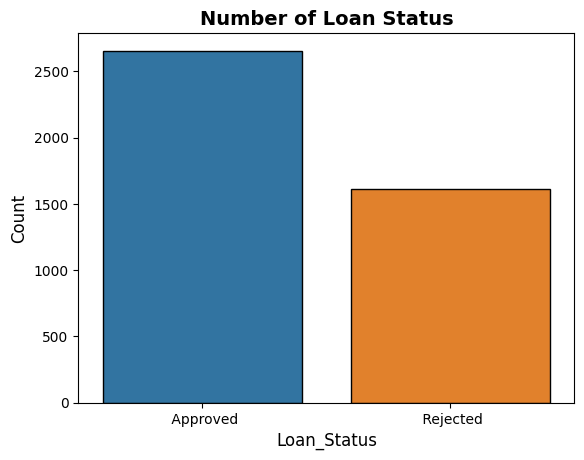

In [14]:
sns.countplot(x='loan_status', data=df ,hue="loan_status", edgecolor='black')
plt.xlabel("Loan_Status", fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.title('Number of Loan Status', fontsize=14, fontweight='bold')
plt.show()

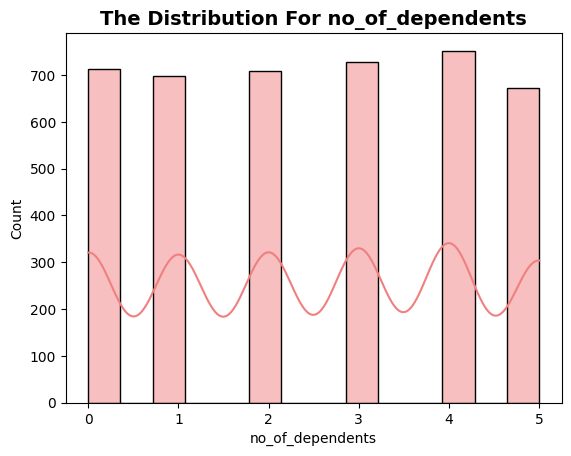

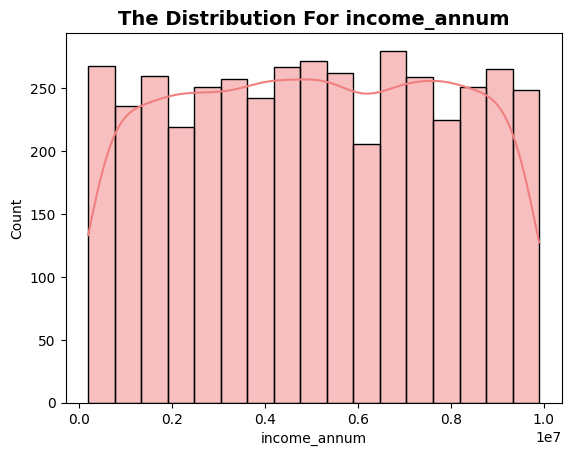

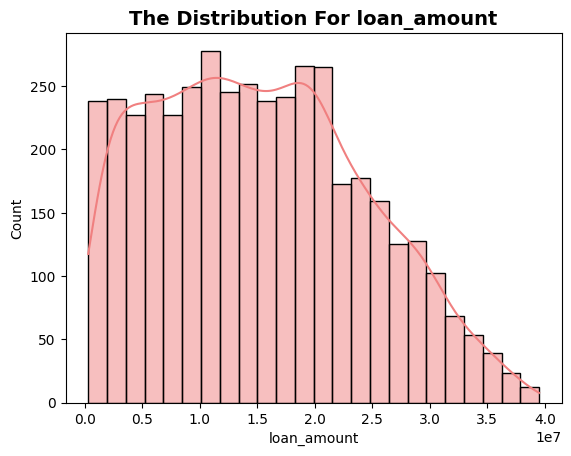

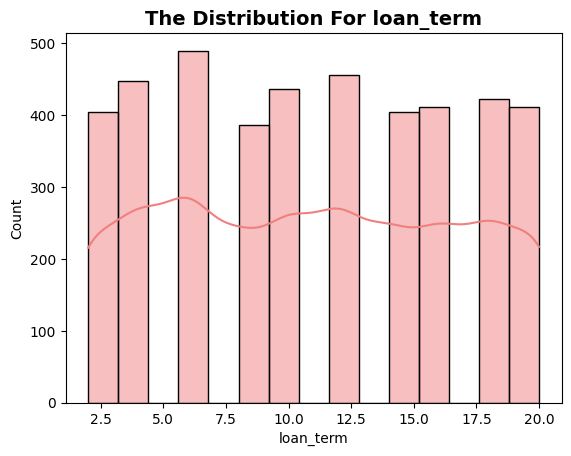

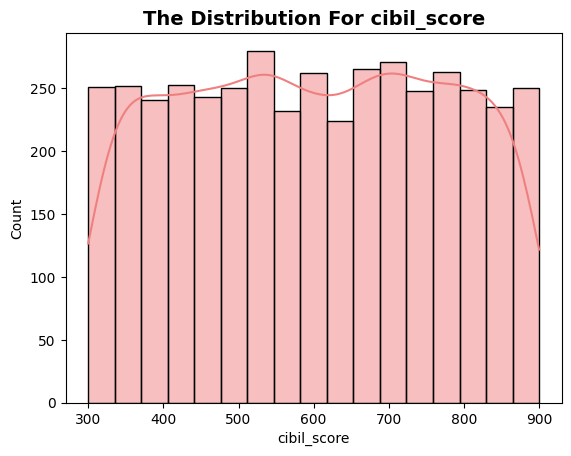

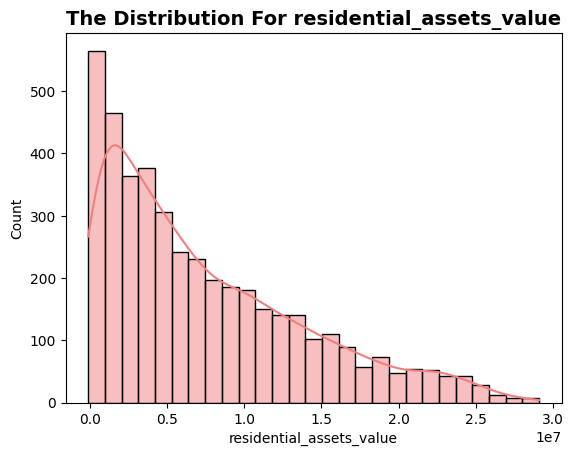

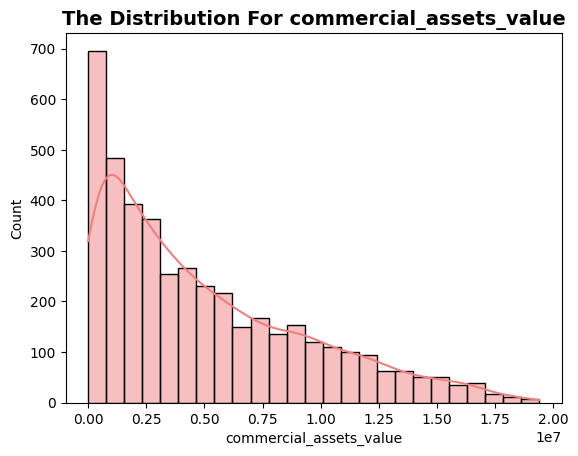

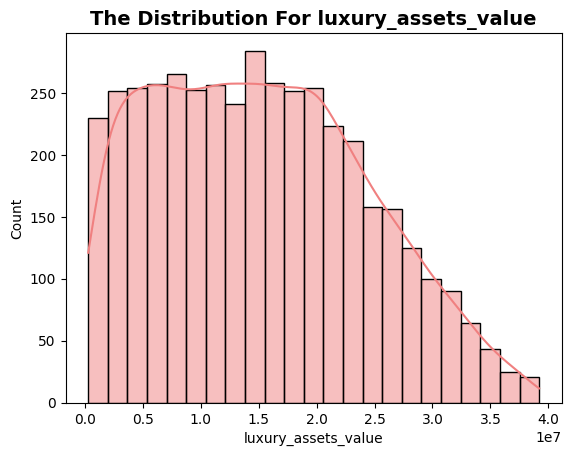

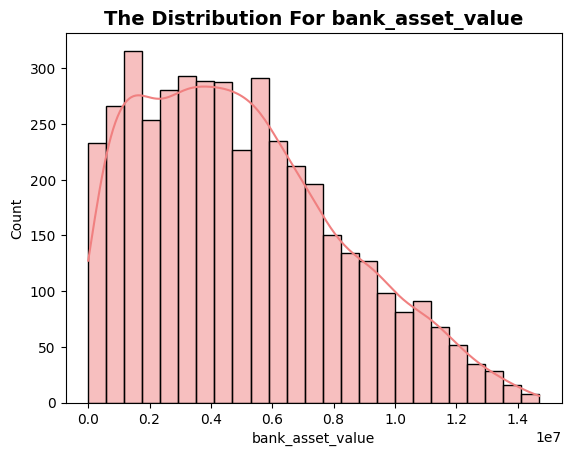

In [17]:
num_cols = [col.strip() for col in num_cols]
for i in num_cols:
    sns.histplot(df[i], kde=True, color='lightcoral', edgecolor='black')
    plt.title(f"The Distribution For {i}" , fontsize=14, fontweight='bold' )
    plt.show()

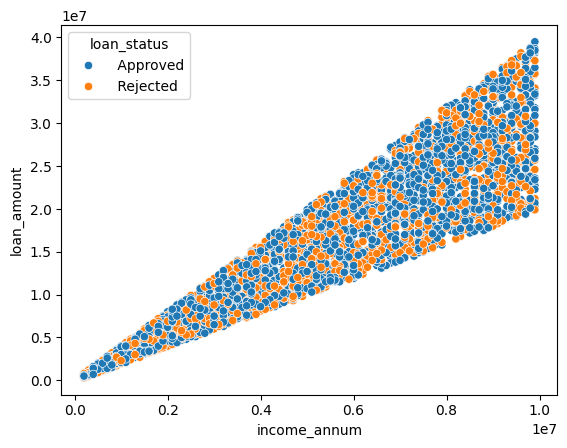

In [162]:
sns.scatterplot(x='income_annum', y='loan_amount', hue='loan_status', data=df)
plt.show()

### OUTLIER DETECTION WITH Z_SCORE 

In [163]:
def detect_outliers_zscore(series, threshold=3.0):
    mean = series.mean()
    std = series.std()
    real_threshold = threshold * std
    lower = mean - real_threshold
    upper = mean + real_threshold
    outliers = series[(series < lower) | (series > upper)]
    return outliers, len(outliers), lower, upper

In [164]:
for feature in num_cols:
    outliers, count, _, _ = detect_outliers_zscore(df[feature])
    print(f'{feature} >> Outliers detected: {count}')
    print("-"*40)

no_of_dependents >> Outliers detected: 0
----------------------------------------
income_annum >> Outliers detected: 0
----------------------------------------
loan_amount >> Outliers detected: 0
----------------------------------------
loan_term >> Outliers detected: 0
----------------------------------------
cibil_score >> Outliers detected: 0
----------------------------------------
residential_assets_value >> Outliers detected: 16
----------------------------------------
commercial_assets_value >> Outliers detected: 17
----------------------------------------
luxury_assets_value >> Outliers detected: 0
----------------------------------------
bank_asset_value >> Outliers detected: 0
----------------------------------------


### OUTLIER DETECTION WITH IQR 

In [165]:
def detect_outliers_iqr(series, lower_percentile=25, upper_percentile=75, factor=1.5):
    Q1 = np.nanpercentile(series, lower_percentile)
    Q3 = np.nanpercentile(series, upper_percentile)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers, len(outliers), lower, upper

In [166]:
for feature in num_cols:
    outliers, count, _, _ = detect_outliers_iqr(df[feature])
    print(f'{feature} >> Outliers detected: {count}')
    print("-"*50)

no_of_dependents >> Outliers detected: 0
--------------------------------------------------
income_annum >> Outliers detected: 0
--------------------------------------------------
loan_amount >> Outliers detected: 0
--------------------------------------------------
loan_term >> Outliers detected: 0
--------------------------------------------------
cibil_score >> Outliers detected: 0
--------------------------------------------------
residential_assets_value >> Outliers detected: 52
--------------------------------------------------
commercial_assets_value >> Outliers detected: 37
--------------------------------------------------
luxury_assets_value >> Outliers detected: 0
--------------------------------------------------
bank_asset_value >> Outliers detected: 5
--------------------------------------------------


## Boxplot To Visualize The Detection oF The Outliers

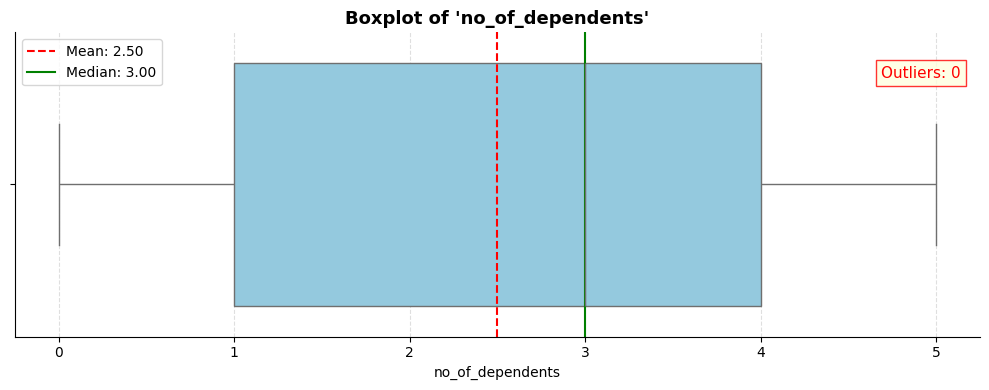

Mean: 2.50 | Median: 3.00 | IQR: 3.00 | Outliers: 0
--------------------------------------------------


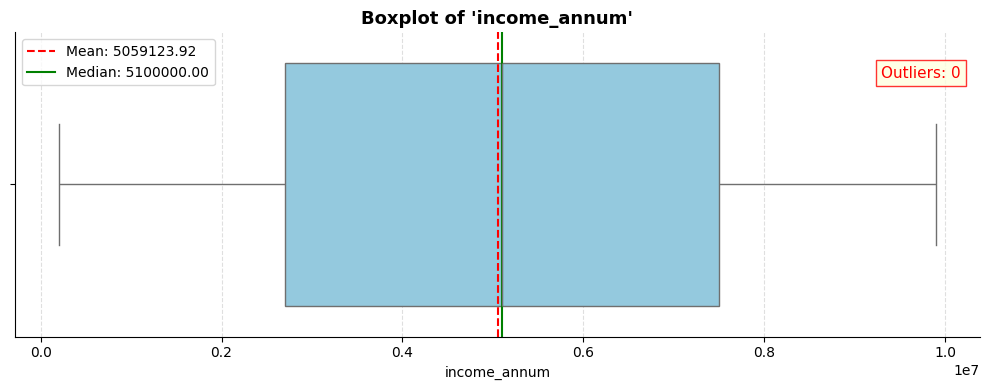

Mean: 5059123.92 | Median: 5100000.00 | IQR: 4800000.00 | Outliers: 0
--------------------------------------------------


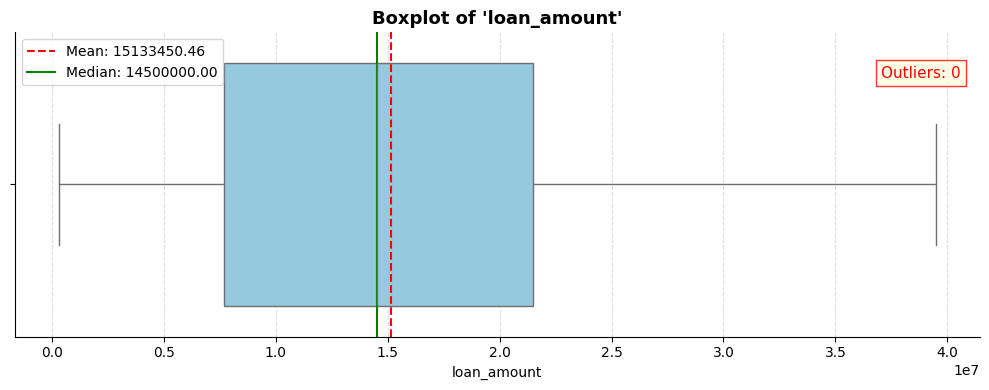

Mean: 15133450.46 | Median: 14500000.00 | IQR: 13800000.00 | Outliers: 0
--------------------------------------------------


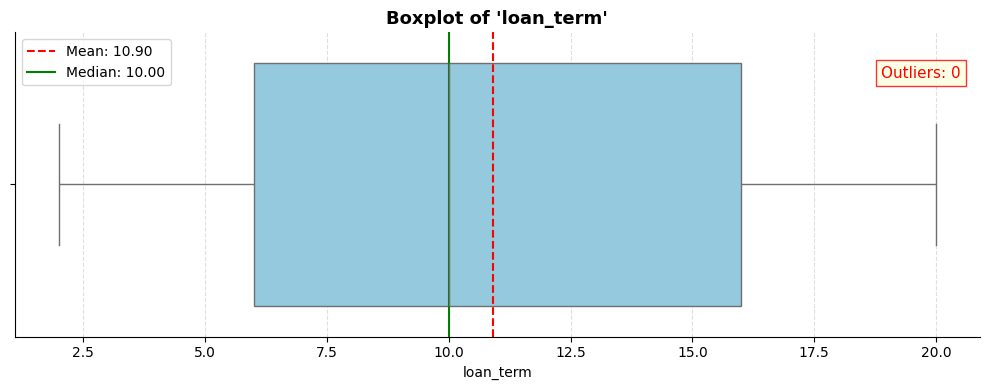

Mean: 10.90 | Median: 10.00 | IQR: 10.00 | Outliers: 0
--------------------------------------------------


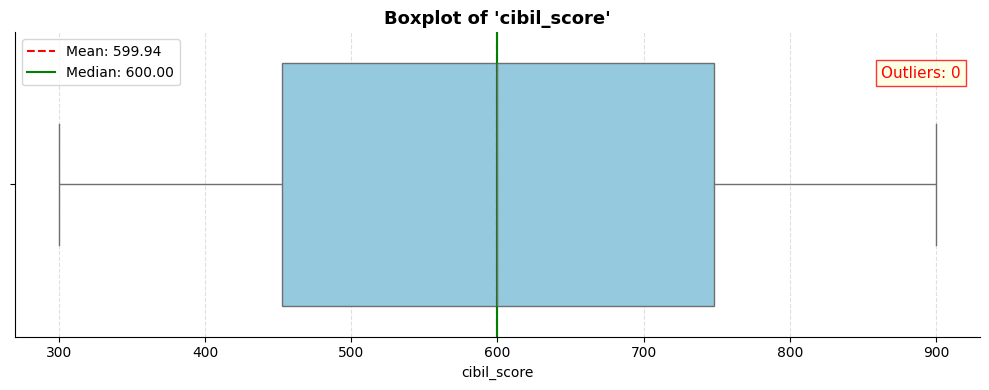

Mean: 599.94 | Median: 600.00 | IQR: 295.00 | Outliers: 0
--------------------------------------------------


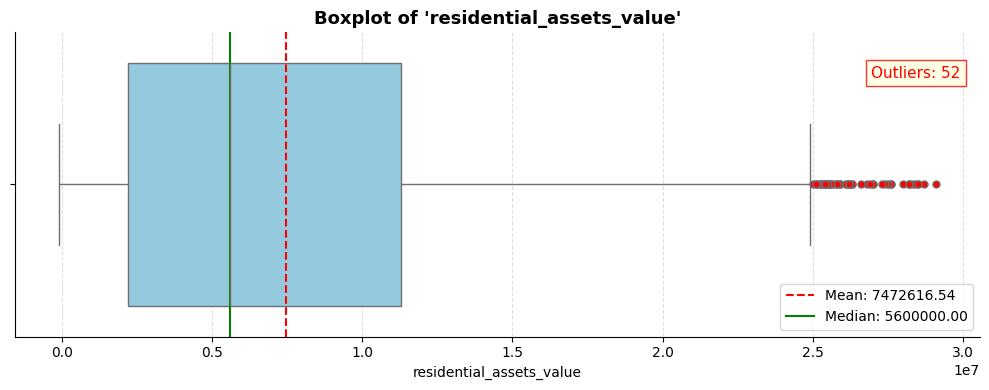

Mean: 7472616.54 | Median: 5600000.00 | IQR: 9100000.00 | Outliers: 52
--------------------------------------------------


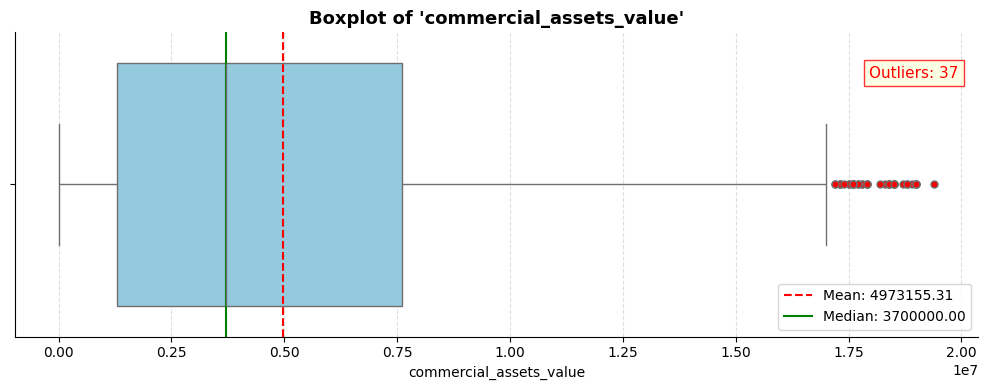

Mean: 4973155.31 | Median: 3700000.00 | IQR: 6300000.00 | Outliers: 37
--------------------------------------------------


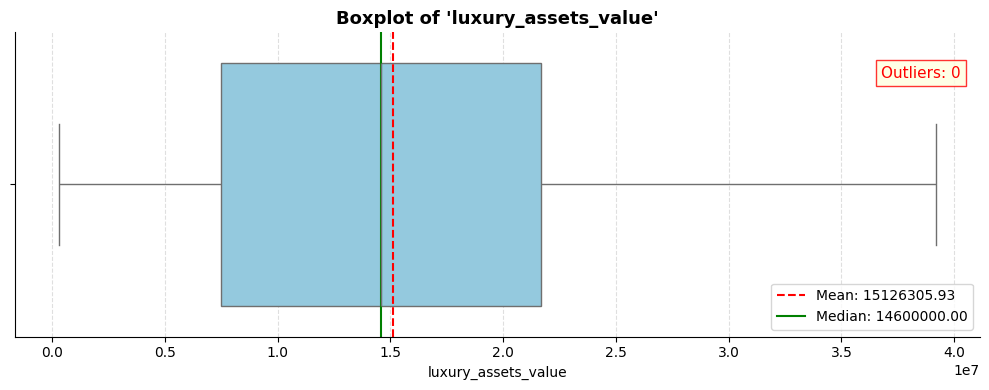

Mean: 15126305.93 | Median: 14600000.00 | IQR: 14200000.00 | Outliers: 0
--------------------------------------------------


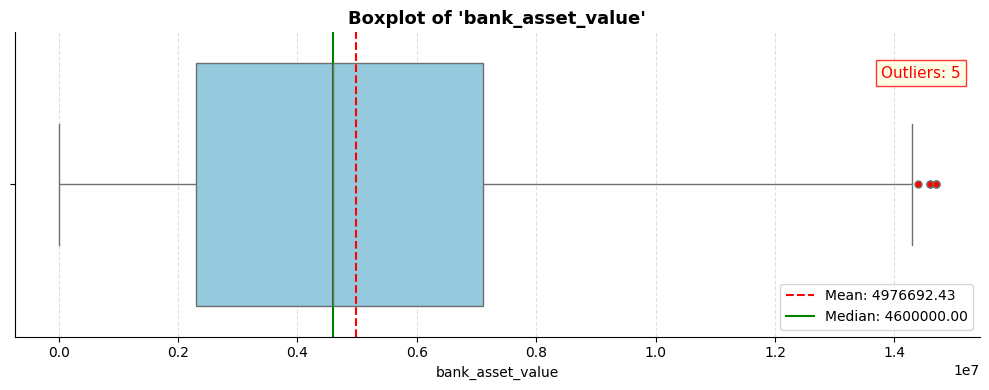

Mean: 4976692.43 | Median: 4600000.00 | IQR: 4800000.00 | Outliers: 5
--------------------------------------------------


In [ ]:
def plot_boxplots(df):
    
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    for col in num_cols:
        Q1     = df[col].quantile(0.25)
        Q3     = df[col].quantile(0.75)
        IQR    = Q3 - Q1
        mean   = df[col].mean()
        median = df[col].median()
        lower  = Q1 - 1.5 * IQR
        upper  = Q3 + 1.5 * IQR
        outliers = len(df[(df[col] < lower) | (df[col] > upper)])
        fig, ax = plt.subplots(figsize=(10, 4))
        
        sns.boxplot(data=df, x=col, ax=ax, color="skyblue",
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=5))

        # Mean and median lines
        ax.axvline(mean,   color="red",   linestyle="--", label=f"Mean: {mean:.2f}")
        ax.axvline(median, color="green", linestyle="-",  label=f"Median: {median:.2f}")

        # Outlier count label
        ax.text(0.98, 0.85, f"Outliers: {outliers}", transform=ax.transAxes,
                ha="right", color="red", fontsize=11,
                bbox=dict(facecolor="lightyellow", edgecolor="red", alpha=0.8))
        ax.set_title(f"Boxplot of '{col}'", fontsize=13, fontweight="bold")
        ax.legend()
        ax.grid(axis="x", linestyle="--", alpha=0.4)
        sns.despine()
        plt.tight_layout()
        plt.show()

        print(f"Mean: {mean:.2f} | Median: {median:.2f} | IQR: {IQR:.2f} | Outliers: {outliers}")
        print("-" * 50)

plot_boxplots(df)

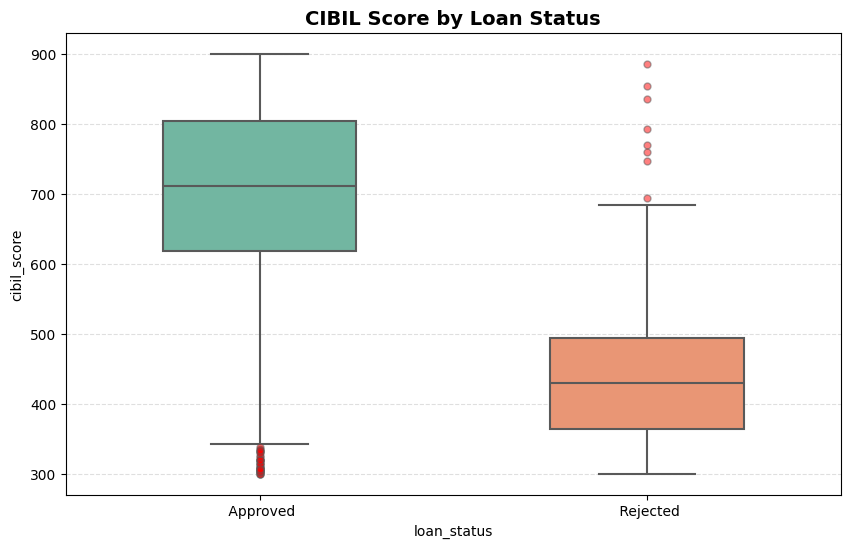

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='loan_status', y='cibil_score', data=df ,hue="loan_status", palette='Set2',width = 0.5,linewidth=1.5,
flierprops= dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))
plt.title("CIBIL Score by Loan Status", fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

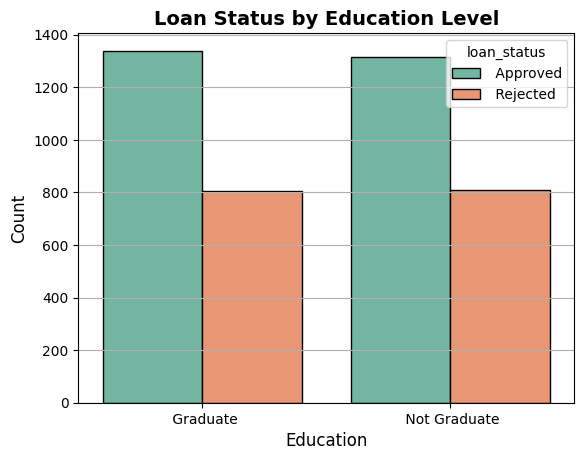

In [29]:
sns.countplot(data=df, x='education',hue="loan_status", edgecolor='black' ,palette='Set2')
plt.title('Loan Status by Education Level', fontsize=14 , fontweight= "bold")
plt.xlabel('Education', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y')
plt.show()

In [30]:
print(df["loan_status"].unique())
print(df["education"].unique())
print(df["self_employed"].unique())

[' Approved' ' Rejected']
[' Graduate' ' Not Graduate']
[' No' ' Yes']


In [31]:
df["loan_status"]=df["loan_status"].map({" Approved":1," Rejected":0})
df["education"]=df["education"].map({" Graduate":1," Not Graduate":0})
df["self_employed"]=df["self_employed"].map({" Yes":1," No":0})

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          4269 non-null   int64
 1   education                 4269 non-null   int64
 2   self_employed             4269 non-null   int64
 3   income_annum              4269 non-null   int64
 4   loan_amount               4269 non-null   int64
 5   loan_term                 4269 non-null   int64
 6   cibil_score               4269 non-null   int64
 7   residential_assets_value  4269 non-null   int64
 8   commercial_assets_value   4269 non-null   int64
 9   luxury_assets_value       4269 non-null   int64
 10  bank_asset_value          4269 non-null   int64
 11  loan_status               4269 non-null   int64
dtypes: int64(12)
memory usage: 400.3 KB


## Heatmap To See The Correlation Between The Features

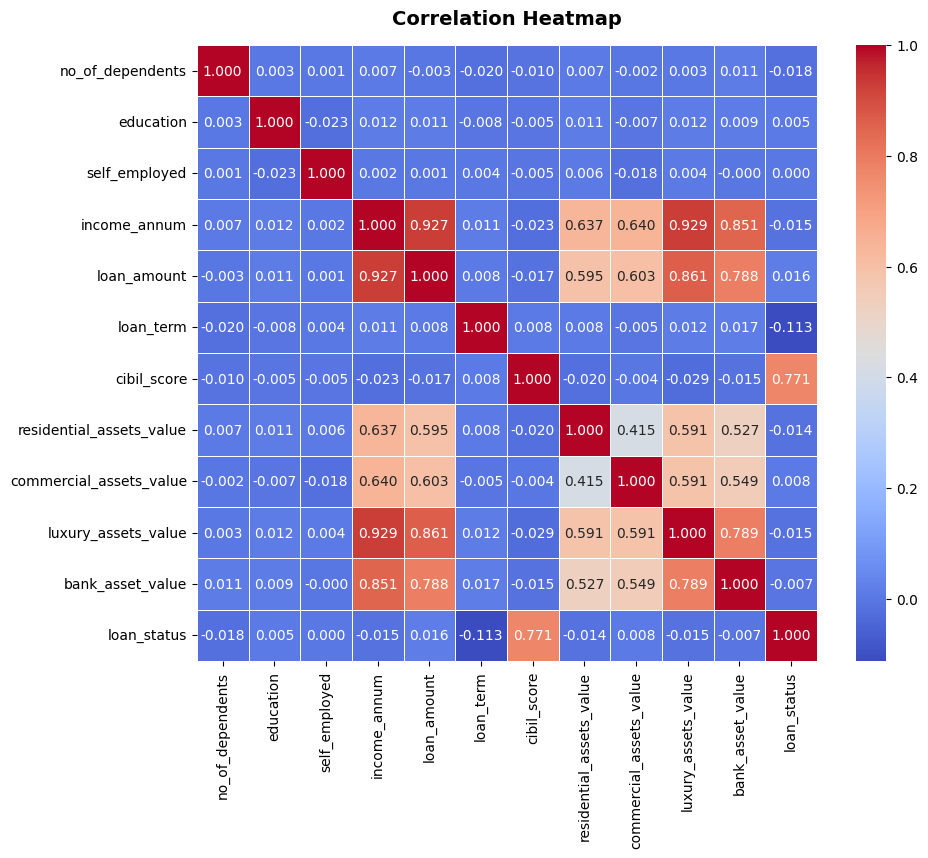

In [42]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True ,cmap="coolwarm" ,linewidths= 0.5,linecolor = "white", fmt= ".3f")
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold", pad=15)
plt.show() 

## Heatmap with Kendall's Method To See The Non-Linear Relationship Between The Features

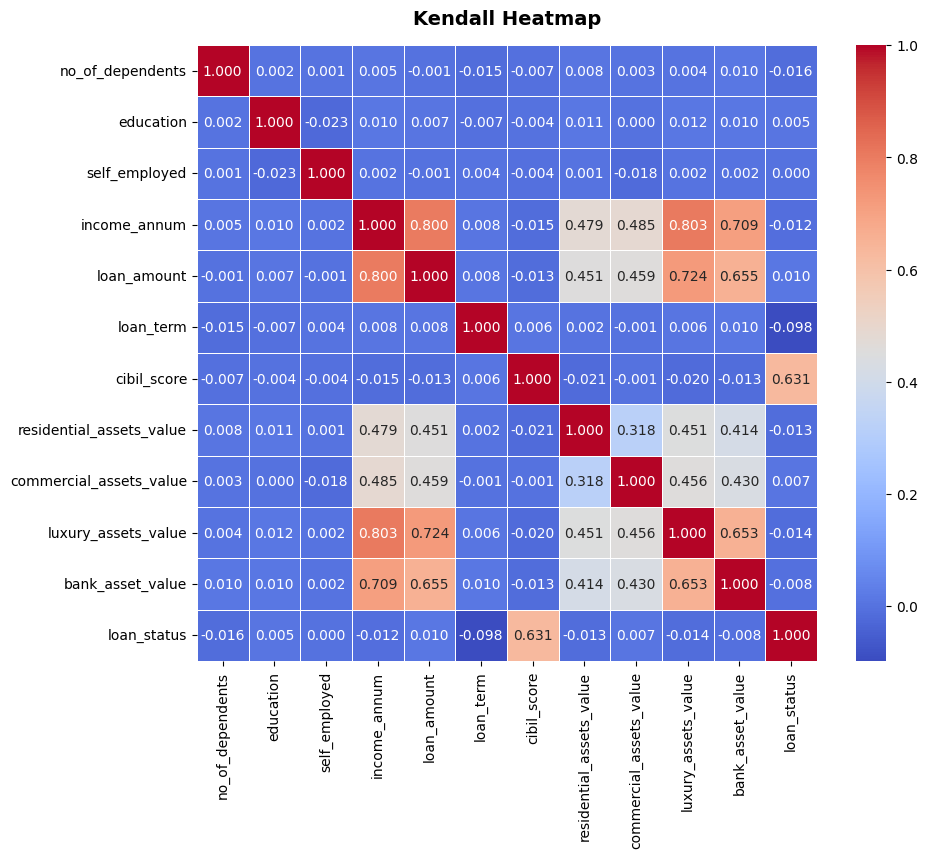

In [46]:
plt.figure(figsize=(10,8))
num_kend=df.corr(method="kendall")
sns.heatmap(num_kend, annot=True ,cmap="coolwarm" ,linewidths= 0.5,linecolor = "white", fmt= ".3f")
plt.title("Kendall Heatmap", fontsize=14, fontweight="bold", pad=15)
plt.show()

## Scaling By RobustScaler

In [47]:
robust =RobustScaler()
for col in num_cols:
    df[col]=robust.fit_transform(df[[col]])
df.head()    


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,-0.333333,1,0,0.937500,1.115942,0.2,0.603390,-0.351648,2.206349,0.570423,0.708333,1
1,-1.000000,0,1,-0.208333,-0.166667,-0.2,-0.620339,-0.318681,-0.238095,-0.408451,-0.270833,0
2,0.000000,1,0,0.833333,1.101449,1.0,-0.318644,0.164835,0.126984,1.316901,1.708333,0
3,0.000000,1,0,0.645833,1.173913,-0.2,-0.450847,1.384615,-0.063492,0.612676,0.687500,0
4,0.666667,0,1,0.979167,0.702899,1.0,-0.738983,0.747253,0.714286,1.042254,0.083333,0


In [48]:
x=df.drop("loan_status", axis=1)
y=df["loan_status"]

## Feature Selection

Mutual Information Scores:
                     Feature  MI_Score
6                cibil_score  0.507937
5                  loan_term  0.018234
1                  education  0.006626
9        luxury_assets_value  0.006186
2              self_employed  0.000630
0           no_of_dependents  0.000000
4                loan_amount  0.000000
3               income_annum  0.000000
7   residential_assets_value  0.000000
8    commercial_assets_value  0.000000
10          bank_asset_value  0.000000



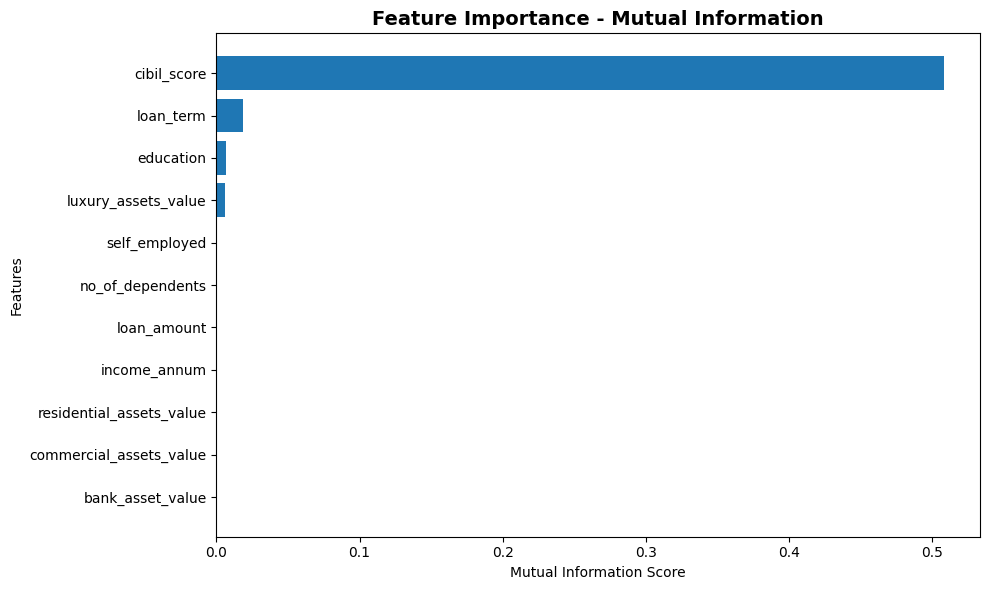


Top 5 most important features:
['cibil_score', 'loan_term', 'education', 'luxury_assets_value', 'self_employed']


In [49]:
mi_scores = mutual_info_classif(x, y, random_state=42)

mi_df = pd.DataFrame({
    'Feature': x.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("Mutual Information Scores:")
print(mi_df)
print()
plt.figure(figsize=(10, 6))
plt.barh(mi_df['Feature'], mi_df['MI_Score'])
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.title('Feature Importance - Mutual Information' , fontsize=14 , fontweight="bold")
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()
top_n = 5
top_features = mi_df.head(top_n)['Feature'].tolist()
print(f"\nTop {top_n} most important features:")
print(top_features)

In [ ]:
#selector = SelectKBest(mutual_info_classif, k=5)
#X_selected = selector.fit_transform(x, y)
#selected_mask = selector.get_support()
#selected_features = x.columns[selected_mask].tolist()
#print(f"Selected features: {selected_features}")

Selected features: ['no_of_dependents', 'income_annum', 'loan_term', 'cibil_score', 'bank_asset_value']


In [52]:
x_train , x_test , y_train , y_test=train_test_split(x,y,test_size=0.2, stratify=y,random_state=42)

## Before Using The Smote Function

## LogisticRegression

In [53]:
logistic = LogisticRegression(max_iter=800,penalty="l1",solver="saga",C=0.1,class_weight='balanced')
logistic.fit(x_train,y_train)
y_pred = logistic.predict(x_test)
test_acc = accuracy_score(y_test,y_pred)
y_pred_proba = logistic.predict_proba(x_test)[:,-1]
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {auc_score:.4f}")
print(f"Test_score: {test_acc:.4f}")


ROC AUC Score: 0.9742
Test_score: 0.9415


c:\Users\mohan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\mohan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


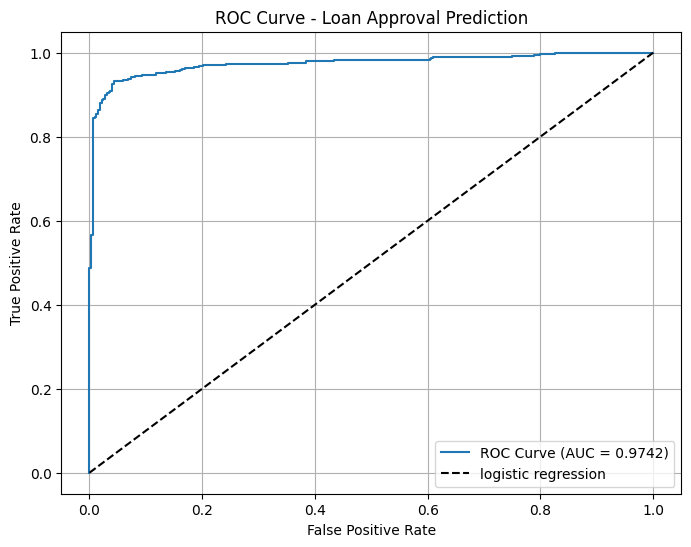

In [54]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='logistic regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Loan Approval Prediction')
plt.legend()
plt.grid(True)
plt.show()

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.90      0.96      0.93       323
    Approved       0.97      0.93      0.95       531

    accuracy                           0.94       854
   macro avg       0.93      0.94      0.94       854
weighted avg       0.94      0.94      0.94       854

------------------------------------------------------------------------------------------


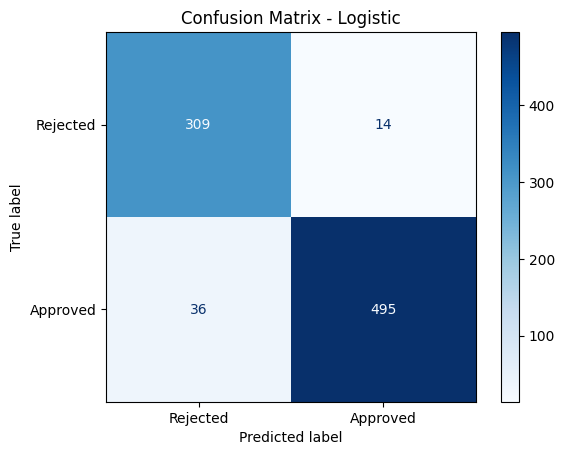

In [55]:
cm = confusion_matrix(y_test, y_pred)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))
print("-"*90)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Rejected', 'Approved'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic')
plt.show()


## RandomForest


In [56]:
rf = RandomForestClassifier(n_estimators=250, class_weight="balanced",random_state=42,n_jobs=-1)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
test_accuracy= accuracy_score(y_test,y_pred)
y_pred_proba = rf.predict_proba(x_test)[:,-1]
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {auc_score:.4f}")
con_met=confusion_matrix(y_test,y_pred)
class_report=classification_report(y_test,y_pred)
print(f"test accuracy: {np.round(test_accuracy,4)}")
print("-"*70)
print(f"confusion matrix")
print(con_met)
print("-"*70)
print(f"classification report: ")
print(class_report)


ROC AUC Score: 0.9989
test accuracy: 0.9801
----------------------------------------------------------------------
confusion matrix
[[313  10]
 [  7 524]]
----------------------------------------------------------------------
classification report: 
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       323
           1       0.98      0.99      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



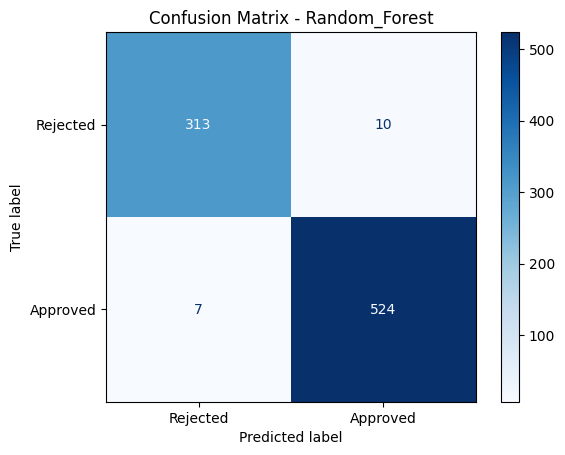

In [57]:
disp = ConfusionMatrixDisplay(confusion_matrix=con_met, 
                               display_labels=['Rejected', 'Approved'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random_Forest')
plt.show()

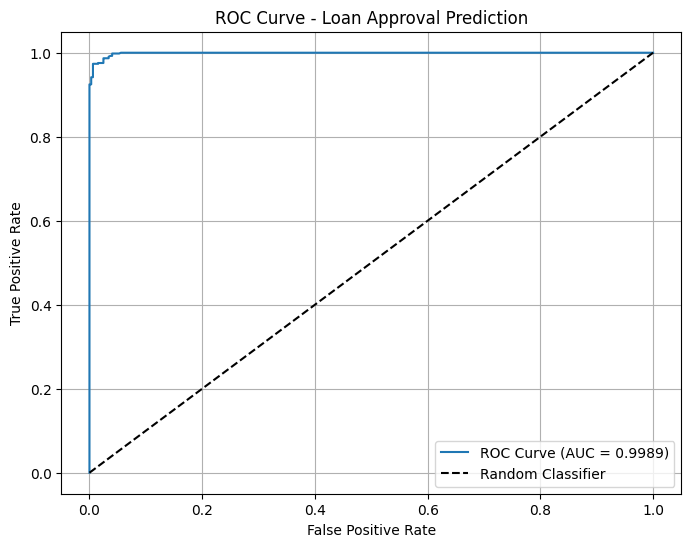

In [58]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Loan Approval Prediction')
plt.legend()
plt.grid(True)
plt.show()

## By Using The SMOTE FUNCTION

In [59]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(x_train, y_train)
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: loan_status
1    2125
0    1290
Name: count, dtype: int64
After SMOTE: loan_status
1    2125
0    2125
Name: count, dtype: int64


## LogisticRegression

In [60]:
logistic = LogisticRegression(max_iter=800,penalty="l1",solver="saga",C=0.1,class_weight='balanced')
logistic.fit(X_train_res,y_train_res)
y_pred = logistic.predict(x_test)
test_acc = accuracy_score(y_test,y_pred)
y_pred_proba = logistic.predict_proba(x_test)[:,-1]
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {auc_score:.4f}")
print(f"Test_score: {test_acc:.4f}")


ROC AUC Score: 0.9741
Test_score: 0.9344


c:\Users\mohan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\mohan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


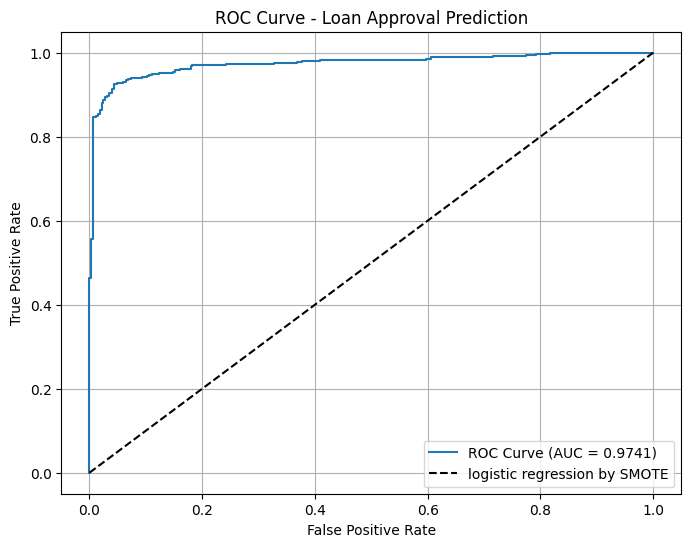

In [61]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='logistic regression by SMOTE')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Loan Approval Prediction')
plt.legend()
plt.grid(True)
plt.show()

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.89      0.94      0.92       323
    Approved       0.96      0.93      0.95       531

    accuracy                           0.93       854
   macro avg       0.93      0.94      0.93       854
weighted avg       0.94      0.93      0.93       854

------------------------------------------------------------------------------------------


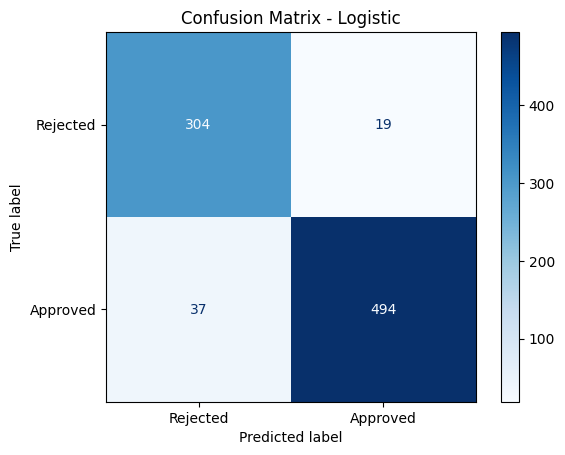

In [62]:
cm = confusion_matrix(y_test, y_pred)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))
print("-"*90)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Rejected', 'Approved'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic')
plt.show()

## RandomForest 

In [63]:
rf = RandomForestClassifier(n_estimators=250, class_weight="balanced",random_state=42,n_jobs=-1)
rf.fit(X_train_res,y_train_res)
y_pred=rf.predict(x_test)
test_accuracy= accuracy_score(y_test,y_pred)
y_pred_proba = rf.predict_proba(x_test)[:,-1]
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {auc_score:.4f}")
con_met=confusion_matrix(y_test,y_pred)
class_report=classification_report(y_test,y_pred)
print(f"test accuracy: {np.round(test_accuracy,4)}")
print("-"*70)
print(f"confusion matrix")
print(con_met)
print("-"*70)
print(f"classification report: ")
print(class_report)

ROC AUC Score: 0.9987
test accuracy: 0.9801
----------------------------------------------------------------------
confusion matrix
[[314   9]
 [  8 523]]
----------------------------------------------------------------------
classification report: 
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       323
           1       0.98      0.98      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



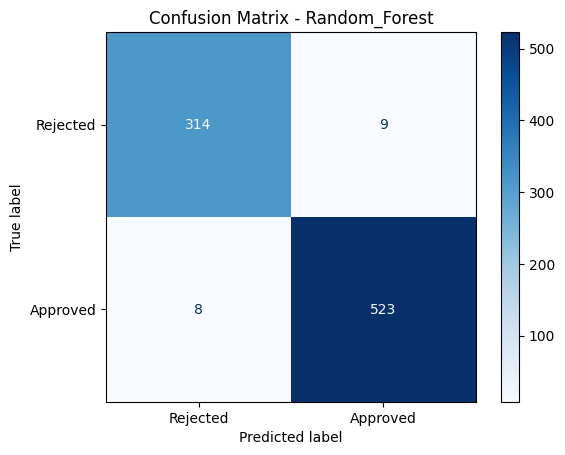

In [64]:
disp = ConfusionMatrixDisplay(confusion_matrix=con_met, 
                               display_labels=['Rejected', 'Approved'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random_Forest')
plt.show()

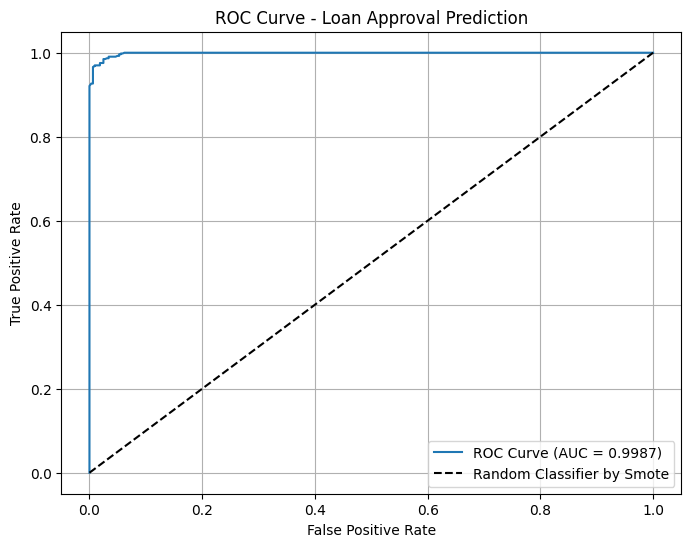

In [65]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier by Smote')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Loan Approval Prediction')
plt.legend()
plt.grid(True)
plt.show()